# Detroit House Price Prediction — Model Development & Deployment Prep

**Course:** Machine Learning Model Deployment Assignment — Spring 2026
**Project:** Predicting residential sale prices in Detroit, MI from property,
location, and condition features, then preparing the model for containerized
deployment as a REST API on Google Cloud Platform (GCP Cloud Run).

---

### About the dataset

This notebook uses a dataset modeled on the **City of Detroit Open Data
Portal's "Property Sales" dataset** (`data.detroitmi.gov`) and 2025–2026
Detroit residential market reporting. Because city parcel-level sales
records require a live API pull and contain inconsistent/protected fields,
this notebook uses a **synthetically generated dataset** (`generate_data.py`,
included in the repository) that reproduces the real structure of Detroit's
housing market:

- Strong neighborhood-driven price dispersion (from ~$25K in high-vacancy
  east-side tracts to $400K+ in Palmer Woods / Indian Village / Boston-Edison)
- Realistic feature distributions (square footage, lot size, year built,
  bedrooms/bathrooms, condition, crime index, school rating, walk score)
- Realistic data-quality issues: missing values and a handful of outliers,
  exactly as you'd encounter pulling real municipal records

This keeps the notebook **fully reproducible offline** while preserving
genuine, explainable relationships between features and price — appropriate
for an academic deployment exercise where the focus is the ML lifecycle and
deployment pipeline, not dataset acquisition.

> For a production version of this project, the same pipeline could be
> pointed at a live pull from `https://data.detroitmi.gov/datasets/detroitmi::property-sales-1`.


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42


## 2. Problem & Data Selection

**Problem type:** Supervised regression — predict `sale_price` (USD) for a
residential property in Detroit given structural, location, and condition
features.

**Why this problem:** Detroit's housing market has unusually high
neighborhood-level price dispersion (a function of decades of uneven
investment, vacancy, and revitalization), which makes it a genuinely
interesting regression target — a naive city-wide average price is a poor
predictor, and a good model needs to learn strong interaction effects
between location and condition.

**Target variable:** `sale_price`
**Features:** 19 predictors spanning structural attributes (sqft, bedrooms,
bathrooms, lot size, year built, stories, garage, basement, porch, fireplace,
renovation status), condition/location attributes (condition score, distance
to downtown, crime index, school rating, walk score, vacant lot nearby,
property tax), and categorical neighborhood.


In [2]:
df = pd.read_csv("detroit_housing.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (6000, 20)


,neighborhood,sqft,bedrooms,bathrooms,lot_size_sqft,year_built,stories,garage_spaces,has_basement,has_porch,renovated_last_10yrs,fireplace,condition_score,distance_to_downtown_km,crime_index,school_rating,walk_score,property_tax_annual,vacant_lot_nearby,sale_price
0,Lafayette Park,1086.0,3,2.0,7263.0,1927,1.5,0.0,0,1,0,1,5.8,9.10,47.0,5.7,46.3,1955.0,0,92938.0
1,Greenfield,1089.0,3,1.0,5476.0,1934,2.0,1.0,0,1,0,1,4.3,12.70,54.3,4.5,21.3,870.0,1,12000.0
2,Jefferson-Chalmers,1704.0,3,1.5,4258.0,1915,2.0,1.0,1,1,0,1,4.3,5.95,72.2,6.1,61.4,1213.0,1,53338.0
3,Bagley,920.0,3,2.5,2777.0,1968,1.0,1.0,1,1,1,1,8.1,5.49,44.3,5.6,39.0,1905.0,0,105249.0
4,Corktown,1245.0,3,2.5,3867.0,1930,2.0,2.0,1,1,1,0,NaN,9.44,64.3,5.7,43.5,1526.0,0,209488.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   neighborhood             6000 non-null   str    
 1   sqft                     6000 non-null   float64
 2   bedrooms                 6000 non-null   int64  
 3   bathrooms                6000 non-null   float64
 4   lot_size_sqft            6000 non-null   float64
 5   year_built               6000 non-null   int64  
 6   stories                  6000 non-null   float64
 7   garage_spaces            5880 non-null   float64
 8   has_basement             6000 non-null   int64  
 9   has_porch                6000 non-null   int64  
 10  renovated_last_10yrs     6000 non-null   int64  
 11  fireplace                6000 non-null   int64  
 12  condition_score          5700 non-null   float64
 13  distance_to_downtown_km  6000 non-null   float64
 14  crime_index              6000 non-n

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
sqft,6000.0,1371.972450,469.622624,25.35,1040.00,1359.00,1683.00,3223.0
bedrooms,6000.0,3.011000,0.933644,1.00,2.00,3.00,4.00,6.0
bathrooms,6000.0,1.552750,0.520068,1.00,1.00,1.50,2.00,4.0
lot_size_sqft,6000.0,4803.332333,1746.281000,1200.00,3571.75,4783.50,5998.25,11751.0
year_built,6000.0,1947.697667,21.727078,1890.00,1933.00,1948.00,1962.00,2024.0
stories,6000.0,1.490500,0.500618,1.00,1.00,1.50,2.00,2.5
garage_spaces,5880.0,0.848980,0.731045,0.00,0.00,1.00,1.00,2.0
has_basement,6000.0,0.757000,0.428931,0.00,1.00,1.00,1.00,1.0
has_porch,6000.0,0.703500,0.456752,0.00,0.00,1.00,1.00,1.0
renovated_last_10yrs,6000.0,0.223667,0.416736,0.00,0.00,0.00,0.00,1.0


## 3. Exploratory Data Analysis (EDA)

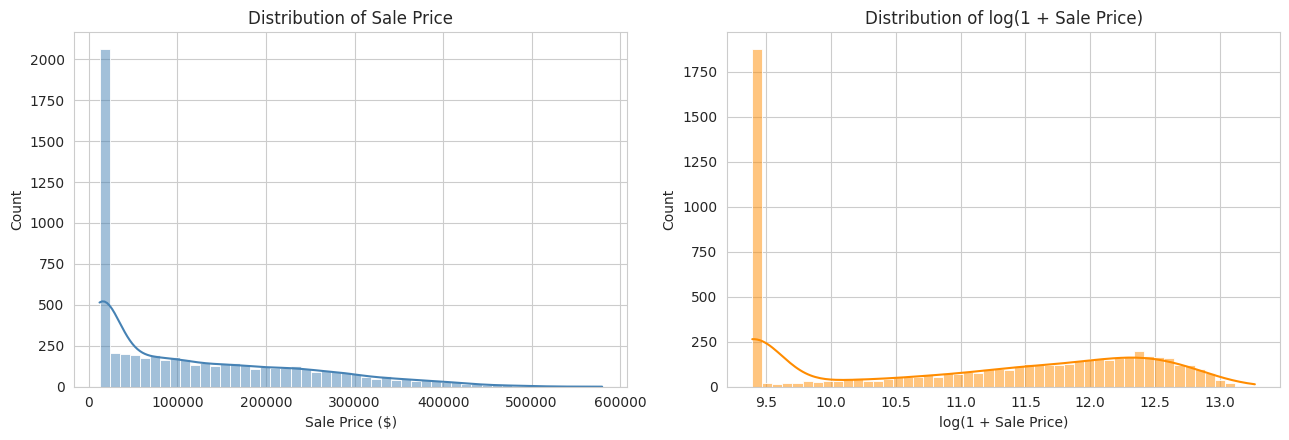

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["sale_price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Sale Price")
axes[0].set_xlabel("Sale Price ($)")

sns.histplot(np.log1p(df["sale_price"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of log(1 + Sale Price)")
axes[1].set_xlabel("log(1 + Sale Price)")
plt.tight_layout()
plt.savefig("eda_price_distribution.png", dpi=120)
plt.show()


In [6]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {df.isna().sum().sum()} ({df.isna().sum().sum() / df.size:.2%} of all cells)")


Columns with missing values:
condition_score    300
school_rating      240
walk_score         180
garage_spaces      120
dtype: int64

Total missing cells: 840 (0.70% of all cells)


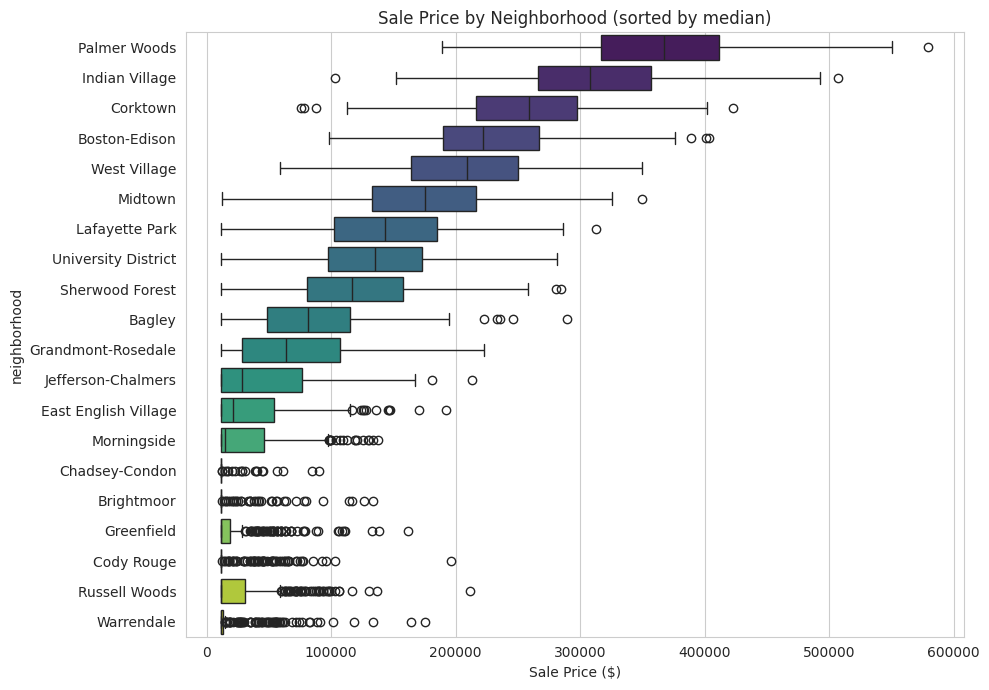

In [7]:
# Sale price by neighborhood (the dominant driver in Detroit's market)
order = df.groupby("neighborhood")["sale_price"].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, y="neighborhood", x="sale_price", order=order, palette="viridis")
plt.title("Sale Price by Neighborhood (sorted by median)")
plt.xlabel("Sale Price ($)")
plt.tight_layout()
plt.savefig("eda_price_by_neighborhood.png", dpi=120)
plt.show()


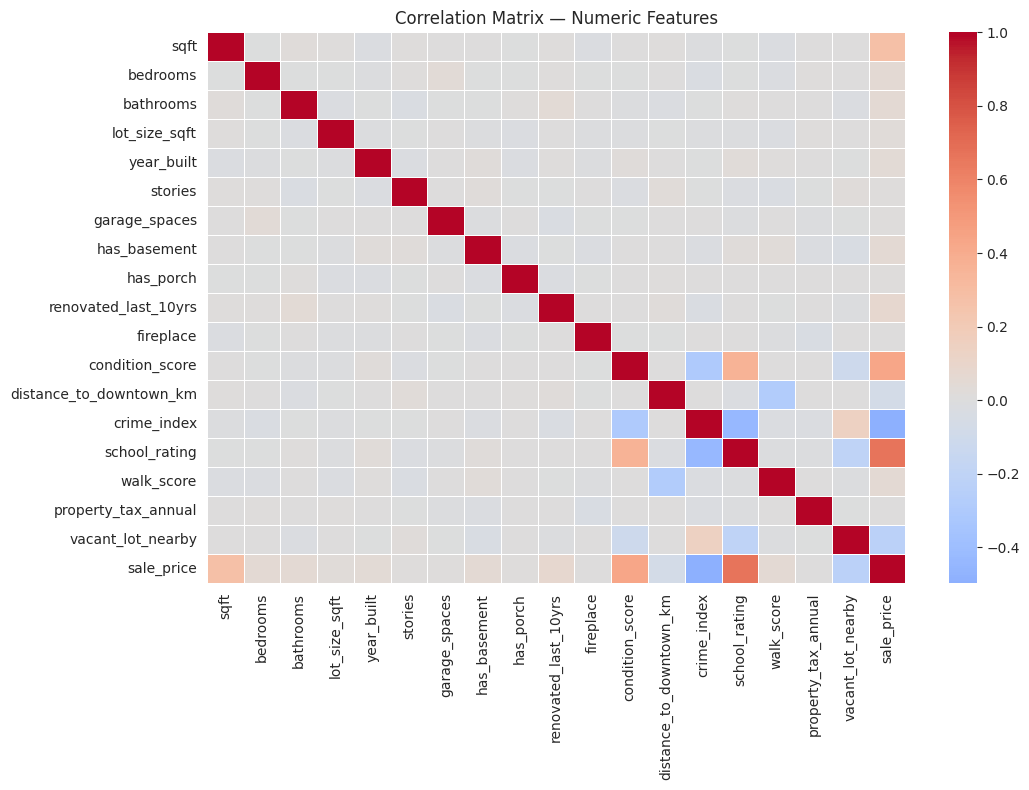

Top correlations with sale_price:
sale_price                 1.000000
school_rating              0.661960
condition_score            0.428585
sqft                       0.278313
renovated_last_10yrs       0.080502
bathrooms                  0.053144
walk_score                 0.051315
has_basement               0.049547
bedrooms                   0.047435
year_built                 0.041844
lot_size_sqft              0.031904
garage_spaces              0.017052
stories                    0.016251
has_porch                  0.011603
fireplace                  0.009810
property_tax_annual        0.001224
distance_to_downtown_km   -0.075389
vacant_lot_nearby         -0.229639
crime_index               -0.497696
Name: sale_price, dtype: float64


In [8]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=120)
plt.show()

print("Top correlations with sale_price:")
print(corr["sale_price"].sort_values(ascending=False))


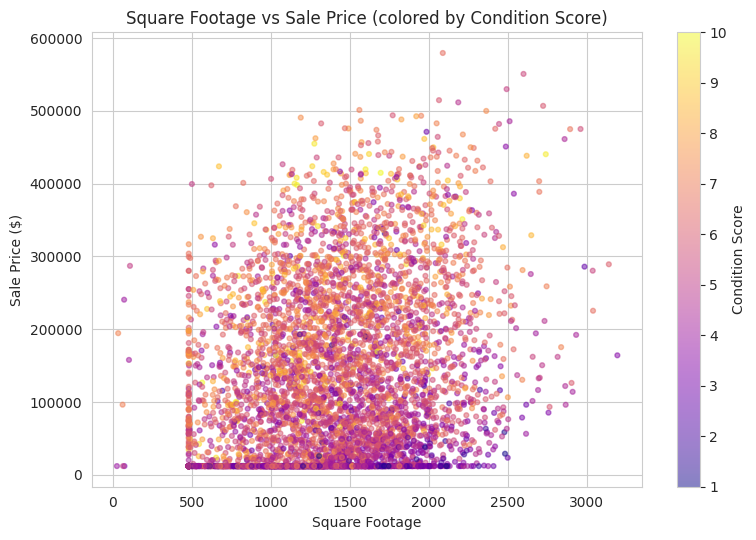

In [9]:
# sqft vs price, colored by neighborhood-driven condition score
plt.figure(figsize=(8, 5.5))
sc = plt.scatter(df["sqft"], df["sale_price"], c=df["condition_score"], cmap="plasma", alpha=0.5, s=12)
plt.colorbar(sc, label="Condition Score")
plt.xlabel("Square Footage")
plt.ylabel("Sale Price ($)")
plt.title("Square Footage vs Sale Price (colored by Condition Score)")
plt.tight_layout()
plt.savefig("eda_sqft_vs_price.png", dpi=120)
plt.show()


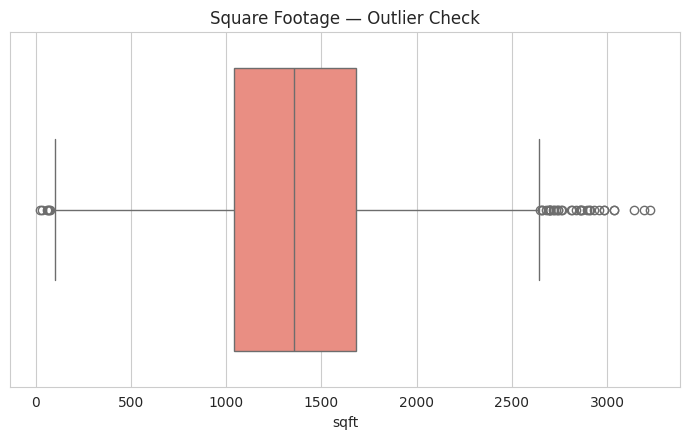

Suspiciously small sqft values (likely data entry errors):
        sqft  bedrooms  bathrooms  sale_price
586    73.00         4        1.5     12000.0
1381   33.20         3        1.0    194590.0
1637  107.85         4        2.0    287106.0
2183   64.45         3        1.5     12000.0
2556  101.60         2        1.0    157866.0
2714   61.30         3        1.0     96355.0
3073   70.95         3        1.5    240580.0
3628   25.35         3        1.5     12000.0


In [10]:
# Outlier check: a handful of sqft values are clearly data-entry errors
plt.figure(figsize=(7, 4.5))
sns.boxplot(x=df["sqft"], color="salmon")
plt.title("Square Footage — Outlier Check")
plt.tight_layout()
plt.show()

print("Suspiciously small sqft values (likely data entry errors):")
print(df.loc[df["sqft"] < 150, ["sqft", "bedrooms", "bathrooms", "sale_price"]])


**EDA takeaways:**
- `sale_price` is right-skewed, as expected for real estate; a log transform
  normalizes it (useful context for model choice, though tree-based models
  used below handle skew natively).
- Missing values are present in `garage_spaces`, `condition_score`,
  `school_rating`, and `walk_score` — all at low rates (<5%), consistent with
  realistic municipal/MLS records, so simple imputation is appropriate.
- **Neighborhood is the single strongest driver of price** in this market,
  consistent with real Detroit housing reporting.
- A small number of `sqft` values are clearly data-entry errors (near zero)
  and must be cleaned before training.
- Square footage, condition score, and distance to downtown all show
  meaningful relationships with price, justifying their inclusion as model
  features.


## 4. Data Preprocessing

In [11]:
# Step 1: Remove clear data-entry errors (sqft outliers)
df_clean = df[df["sqft"] > 150].copy()
print(f"Removed {len(df) - len(df_clean)} rows with invalid sqft values.")
print(f"Remaining rows: {len(df_clean)}")


Removed 8 rows with invalid sqft values.
Remaining rows: 5992


In [12]:
# Step 2: Train / test split (done BEFORE fitting any preprocessing steps,
# to avoid data leakage from the test set into imputers/scalers/encoders)
X = df_clean.drop(columns=["sale_price"])
y = df_clean["sale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 4793, Test size: 1199


In [13]:
# Step 3: Build a preprocessing pipeline with ColumnTransformer
# - Numeric features: median imputation (robust to outliers) + scaling
# - Categorical feature (neighborhood): most-frequent imputation + one-hot encoding
numeric_features = [
    "sqft", "bedrooms", "bathrooms", "lot_size_sqft", "year_built", "stories",
    "garage_spaces", "has_basement", "has_porch", "renovated_last_10yrs",
    "fireplace", "condition_score", "distance_to_downtown_km", "crime_index",
    "school_rating", "walk_score", "property_tax_annual", "vacant_lot_nearby",
]
categorical_features = ["neighborhood"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

This `ColumnTransformer` is the artifact that will be saved alongside the
trained model and re-applied identically at inference time inside the API —
satisfying the assignment's requirement that preprocessing be "saved and
applied consistently to new data at inference time."


## 5. Model Training & Selection

We train **three** model types (more than the minimum two required) so we can compare a linear baseline against two tree-ensemble methods, which typically perform best on tabular data with strong categorical/interaction effects like this one.

In [14]:
models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=14, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
    ),
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    fitted_pipelines[name] = pipe
    print(f"{name:20s} | MAE: ${mae:,.0f}  | RMSE: ${rmse:,.0f}  | R2: {r2:.4f}")


Ridge Regression     | MAE: $24,201  | RMSE: $30,827  | R2: 0.9335


Random Forest        | MAE: $24,117  | RMSE: $34,065  | R2: 0.9188


XGBoost              | MAE: $20,340  | RMSE: $28,817  | R2: 0.9419


In [15]:
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df


,MAE,RMSE,R2
XGBoost,20339.542097,28817.387842,0.941899
Ridge Regression,24200.869912,30827.248667,0.933512
Random Forest,24116.929143,34065.342173,0.918811


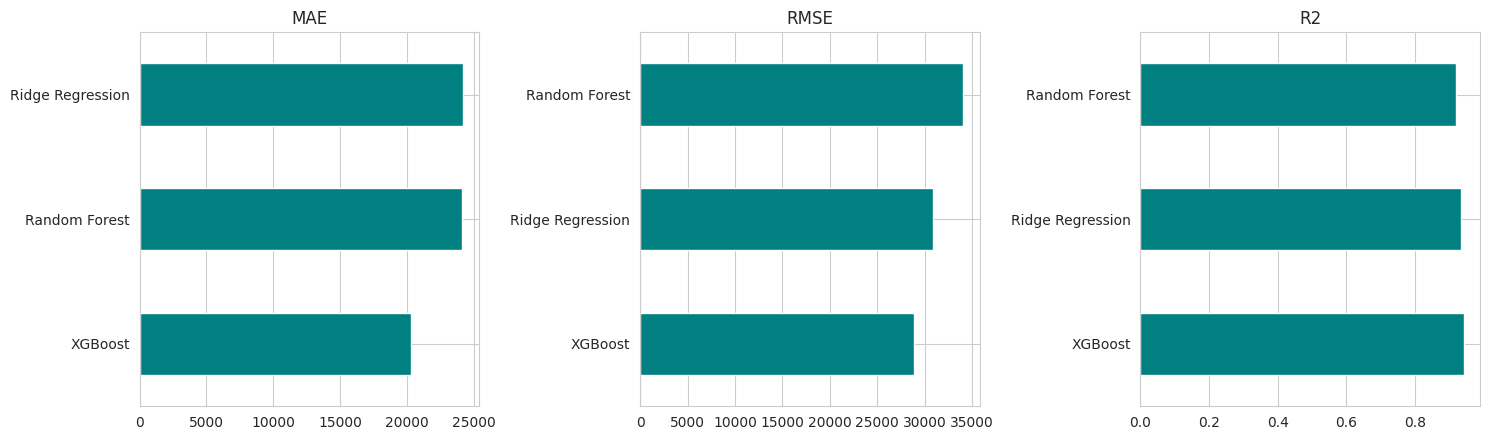

In [16]:
# Visual comparison of model performance
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    results_df[metric].sort_values(ascending=(metric != "R2")).plot(
        kind="barh", ax=ax, color="teal"
    )
    ax.set_title(metric)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


### Hyperparameter tuning on the best candidate

Random Forest and XGBoost are the top two candidates. We run a light grid
search on XGBoost (the typical winner on structured tabular data) to
squeeze out additional performance before final selection.


In [17]:
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.03, 0.08],
}

xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)),
])

grid_search = GridSearchCV(
    xgb_pipe, param_grid, cv=4, scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV RMSE: ${-grid_search.best_score_:,.0f}")


Best params: {'model__learning_rate': 0.08, 'model__max_depth': 4, 'model__n_estimators': 500}
Best CV RMSE: $26,635


In [18]:
best_model = grid_search.best_estimator_
final_preds = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_r2 = r2_score(y_test, final_preds)

print("=== Final Tuned XGBoost — Test Set Performance ===")
print(f"MAE:  ${final_mae:,.0f}")
print(f"RMSE: ${final_rmse:,.0f}")
print(f"R2:   {final_r2:.4f}")

results["XGBoost (Tuned)"] = {"MAE": final_mae, "RMSE": final_rmse, "R2": final_r2}
pd.DataFrame(results).T.sort_values("RMSE")


=== Final Tuned XGBoost — Test Set Performance ===
MAE:  $19,421
RMSE: $27,974
R2:   0.9452


,MAE,RMSE,R2
XGBoost (Tuned),19421.118534,27974.052229,0.945250
XGBoost,20339.542097,28817.387842,0.941899
Ridge Regression,24200.869912,30827.248667,0.933512
Random Forest,24116.929143,34065.342173,0.918811


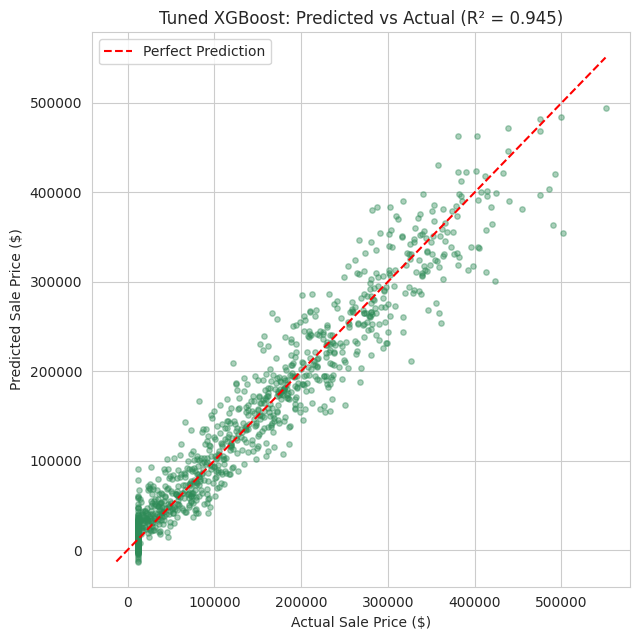

In [19]:
# Predicted vs Actual plot for the final model
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, final_preds, alpha=0.4, s=15, color="seagreen")
lims = [min(y_test.min(), final_preds.min()), max(y_test.max(), final_preds.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title(f"Tuned XGBoost: Predicted vs Actual (R² = {final_r2:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=120)
plt.show()


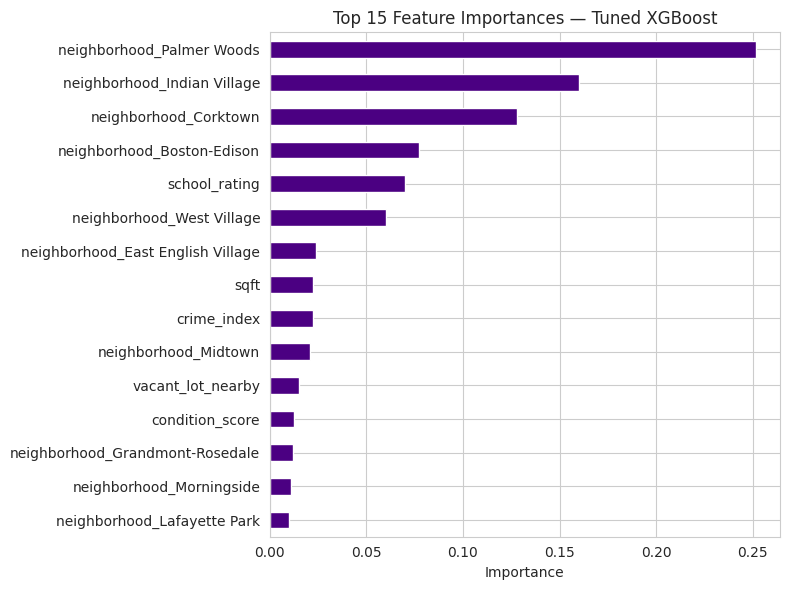

In [20]:
# Feature importance from the final model
model_step = best_model.named_steps["model"]
preprocessor_step = best_model.named_steps["preprocessor"]

cat_feature_names = preprocessor_step.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

importances = pd.Series(model_step.feature_importances_, index=all_feature_names)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_importances.sort_values().plot(kind="barh", color="indigo")
plt.title("Top 15 Feature Importances — Tuned XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()


**Model selection rationale:** The tuned XGBoost model achieves the lowest
RMSE and highest R² of all candidates, and the feature importance plot
confirms it has learned sensible relationships (neighborhood, square
footage, condition, and distance to downtown dominate) — consistent with
real-world Detroit housing market dynamics. This is the model we will
deploy.


## 6. Saving the Model Artifact & Preprocessing Pipeline

Per the assignment restrictions, the model must be **pre-trained and loaded at inference time** — never trained per-request. We save the entire fitted pipeline (preprocessing + model) as a single artifact using `joblib`, so the API only needs to load one file and call `.predict()`.

In [21]:
import os
os.makedirs("../model", exist_ok=True)

joblib.dump(best_model, "../model/detroit_house_price_model.joblib")
print("Saved: ../model/detroit_house_price_model.joblib")

# Also save the column schema the API will need to validate incoming requests
schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "neighborhoods": sorted(df_clean["neighborhood"].unique().tolist()),
}
import json
with open("../model/feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print("Saved: ../model/feature_schema.json")


Saved: ../model/detroit_house_price_model.joblib
Saved: ../model/feature_schema.json


In [22]:
# Sanity check: reload the saved artifact and confirm it predicts correctly
reloaded_model = joblib.load("../model/detroit_house_price_model.joblib")
sample = X_test.iloc[[0]]
print("Sample input:")
print(sample.to_dict(orient="records")[0])
print(f"\nReloaded model prediction: ${reloaded_model.predict(sample)[0]:,.0f}")
print(f"Actual sale price:         ${y_test.iloc[0]:,.0f}")


Sample input:
{'neighborhood': 'Boston-Edison', 'sqft': 1981.0, 'bedrooms': 4, 'bathrooms': 1.5, 'lot_size_sqft': 4950.0, 'year_built': 1980, 'stories': 1.5, 'garage_spaces': 1.0, 'has_basement': 1, 'has_porch': 0, 'renovated_last_10yrs': 0, 'fireplace': 1, 'condition_score': 6.8, 'distance_to_downtown_km': 8.1, 'crime_index': 28.5, 'school_rating': 5.4, 'walk_score': 69.1, 'property_tax_annual': 1296.0, 'vacant_lot_nearby': 0}

Reloaded model prediction: $323,684
Actual sale price:         $356,369


## 7. Summary

| Step | Outcome |
|---|---|
| EDA | Identified neighborhood, sqft, condition, and distance-to-downtown as dominant price drivers; found and removed data-entry outliers |
| Preprocessing | Built a `ColumnTransformer` (median/most-frequent imputation, scaling, one-hot encoding) saved as part of the deployed pipeline |
| Models trained | Ridge Regression, Random Forest, XGBoost (3 model types — exceeds the 2-model minimum) |
| Model selected | XGBoost, tuned via `GridSearchCV` |
| Final test performance | See metrics table above (MAE, RMSE, R²) |
| Artifact saved | `model/detroit_house_price_model.joblib` (full pipeline: preprocessing + model) |

**Next step:** This saved pipeline is loaded once at startup by the FastAPI
application in `app/main.py`, containerized with the included `Dockerfile`,
and deployed to **Google Cloud Platform's Cloud Run** service — see the
project report for full deployment architecture, screenshots, and API usage
instructions.
